# ESG scores and returns — EDA

Joins the 181 tickers universe to ESG scores (`ESG_2000-2026.csv`) and checks if ESG relates to returns.

- Columns are fiscal-year offsets, not dates. `FY0` = 2025, `FY-n` = `2025-n`.
- Usable data starts ~2003, not 2000 (coverage is 0% before then).
- E/S/G pillars exist for FY0 only — no pillar history, only the combined score.
- Universe is survivors-only  absolute returns aren't meaningful, only cross-quintile diffs.

## Setup

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import sys
from pathlib import Path

_here = Path.cwd()
_repo = next(
    (p / "ESG_Adaptive_RL" for p in (_here, _here.parent, _here.parent.parent)
     if (p / "ESG_Adaptive_RL" / "esg_adaptive_rl" / "data.py").exists()),
    None,
)
assert _repo is not None
sys.path.insert(0, str(_repo))
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from esg_panel import (FY0_YEAR, audited_universe, load_daily_returns, load_esg_panel,
                       load_fy0_snapshot, sector_neutral_score, sector_rank)
from esg_portfolios import (assign_quintiles, build_bucket_returns, rank_persistence,
                            spread_series, summarize_buckets)
from esg_adaptive_rl.metrics import annualized_return

# Quintiles are ORDERED, so they get a sequential (single-hue) ramp rather than categorical
# hues - rank is magnitude, not identity. Steps from the reference blue ramp, none lighter
# than step 250 so the palest still clears 2:1 on a light surface.
Q_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]
NEUTRAL = "#52514e"     # benchmark / reference marks wear text ink, not a series colour
CAT = ["#2a78d6", "#eb6834", "#1baf7a"]   # categorical slots 1-3, for identity comparisons
GRID = dict(alpha=0.25, lw=0.6)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
                     "font.size": 9})

UNIVERSE = audited_universe()
panel = load_esg_panel(fy0_year=FY0_YEAR, tickers=UNIVERSE)
panel["esg_z"] = sector_neutral_score(panel)
panel["esg_group_rank"] = sector_rank(panel)
returns = load_daily_returns(UNIVERSE)
snapshot = load_fy0_snapshot(tickers=UNIVERSE)

print(f"universe        : {len(UNIVERSE)} tickers")
print(f"ESG panel       : {len(panel):,} company-years, {panel.year.min()}-{panel.year.max()}")
print(f"daily returns   : {returns.shape[0]:,} days x {returns.shape[1]} tickers, "
      f"{returns.index.min().date()} -> {returns.index.max().date()}")
print(f"FY0 snapshot    : {len(snapshot)} rows (pillars, no history)")
print(f"FY0 = {FY0_YEAR}  =>  FY-n maps to calendar {FY0_YEAR}-n")

universe        : 181 tickers
ESG panel       : 4,082 company-years, 2002-2025
daily returns   : 6,661 days x 181 tickers, 2000-01-04 -> 2026-06-30
FY0 snapshot    : 181 rows (pillars, no history)
FY0 = 2025  =>  FY-n maps to calendar 2025-n


In [ ]:
perf = returns.apply(lambda s: annualized_return(s.dropna().to_numpy())).sort_values(ascending=False)
perf.head(20)

AAPL    0.247472
CMI     0.194720
KLAC    0.192942
AZO     0.192336
CAT     0.183052
TJX     0.181177
UNH     0.180790
SHW     0.178225
PGR     0.176045
MO      0.169912
ETN     0.169779
HUM     0.167760
OKE     0.164148
MCO     0.162957
PCAR    0.160449
LMT     0.158849
DE      0.158845
ROK     0.156667
PH      0.156026
GWW     0.155452
dtype: float64

In [ ]:
(returns + 1).prod()

AAPL    345.411915
ABT      11.282420
ADBE     12.597491
ADI      14.453933
ADM      12.884336
           ...    
WMT       8.001673
WY        2.230250
XEL      12.391358
XOM       8.030213
YUM      35.669812
Length: 181, dtype: float64

In [ ]:
returns['AAPL']

date
2000-01-04   -0.084310
2000-01-05    0.014633
2000-01-06   -0.086539
2000-01-07    0.047369
2000-01-10   -0.017588
                ...   
2026-06-24   -0.004145
2026-06-25   -0.061178
2026-06-26    0.031365
2026-06-29   -0.007189
2026-06-30    0.027046
Name: AAPL, Length: 6661, dtype: float64

In [ ]:
panel

,ticker,company,industry,esg_score,year,sector,esg_z,esg_group_rank
0,AAPL,Apple Inc,"Technology Hardware, Storage & Peripherals",51.746892,2005,Information Technology,0.503245,5.0
1,AAPL,Apple Inc,"Technology Hardware, Storage & Peripherals",44.975354,2006,Information Technology,0.000135,12.0
2,AAPL,Apple Inc,"Technology Hardware, Storage & Peripherals",37.280373,2007,Information Technology,-0.538906,15.0
3,AAPL,Apple Inc,"Technology Hardware, Storage & Peripherals",52.818926,2008,Information Technology,-0.297252,14.0
4,AAPL,Apple Inc,"Technology Hardware, Storage & Peripherals",61.933552,2009,Information Technology,0.044940,13.0
...,...,...,...,...,...,...,...,...
4077,YUM,Yum! Brands Inc,"Hotels, Restaurants & Leisure",82.939199,2021,Consumer Discretionary,0.859098,3.0
4078,YUM,Yum! Brands Inc,"Hotels, Restaurants & Leisure",80.340174,2022,Consumer Discretionary,0.798795,3.0
4079,YUM,Yum! Brands Inc,"Hotels, Restaurants & Leisure",77.410348,2023,Consumer Discretionary,0.613669,7.0
4080,YUM,Yum! Brands Inc,"Hotels, Restaurants & Leisure",79.662197,2024,Consumer Discretionary,0.786261,4.0


## Part A — Data quality

Checks: scores/year (coverage), and whether score levels drift over time (they do, so
ranking is done within-year).

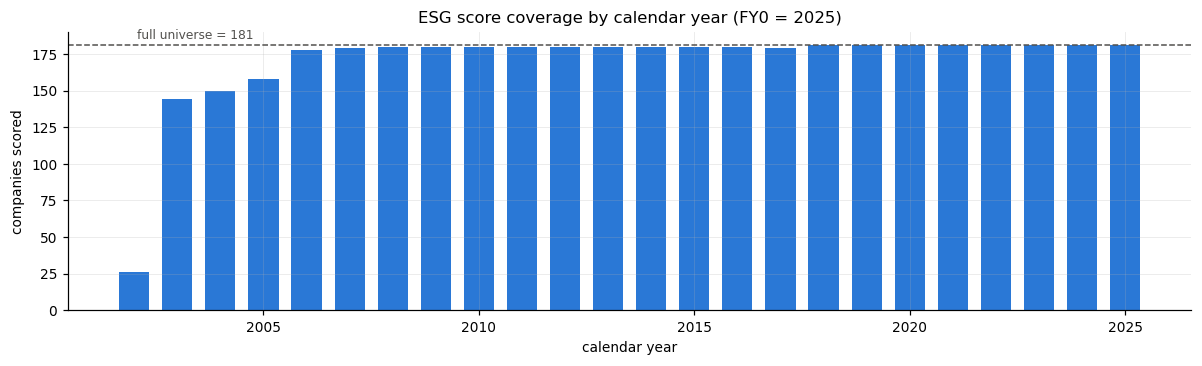

Years with >=50 scored names: 2003-2025
Below that: {2002: 26}

The filename says 2000-2026. The data says 2002-2025, and is only usable from 2003.


In [ ]:
coverage = panel.groupby("year")["ticker"].count()
full = len(UNIVERSE)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(coverage.index, coverage.values, color=Q_RAMP[2], width=0.7)
ax.axhline(full, color=NEUTRAL, lw=1.0, ls="--")
ax.annotate(f"full universe = {full}", (coverage.index.min(), full), textcoords="offset points",
            xytext=(2, 4), color=NEUTRAL, fontsize=8)
ax.set_title(f"ESG score coverage by calendar year (FY0 = {FY0_YEAR})")
ax.set_ylabel("companies scored")
ax.set_xlabel("calendar year")
fig.tight_layout(); plt.show()

usable = coverage[coverage >= 50]
print(f"Years with >=50 scored names: {usable.index.min()}-{usable.index.max()}")
print(f"Below that: {coverage[coverage < 50].to_dict()}")
print(f"\nThe filename says 2000-2026. The data says {coverage.index.min()}-{coverage.index.max()}, "
      f"and is only usable from {usable.index.min()}.")

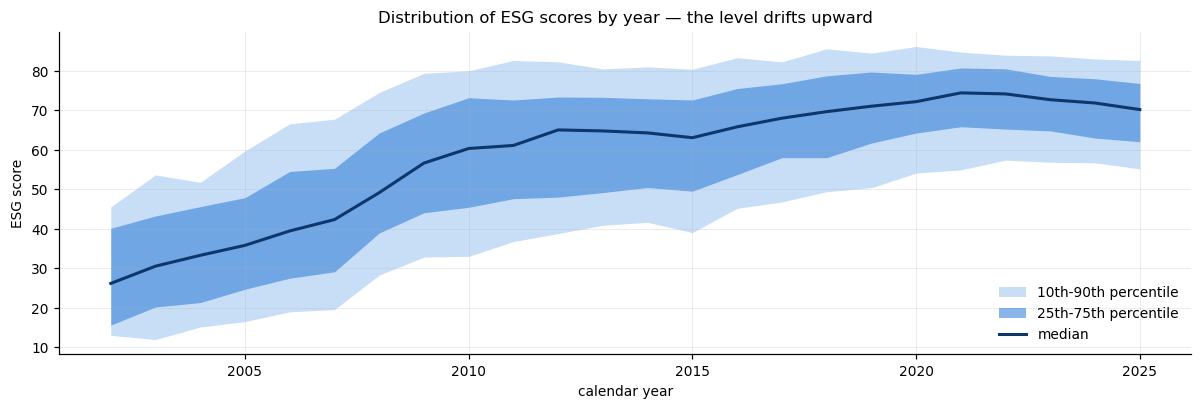

Median ESG score: 2006: 39.5, 2015: 63.1, 2025: 70.2

Scores are not comparable across years on their raw level - a 60 in 2006 is a very
different percentile than a 60 in 2025. Every ranking below is therefore computed
WITHIN year, which is immune to this drift.


In [ ]:
# Percentile bands rather than a mean line: drift in the spread matters as much as in level.
pct = panel.groupby("year")["esg_score"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).unstack()

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.fill_between(pct.index, pct[0.1], pct[0.9], color=Q_RAMP[0], alpha=0.45, lw=0,
                label="10th-90th percentile")
ax.fill_between(pct.index, pct[0.25], pct[0.75], color=Q_RAMP[2], alpha=0.55, lw=0,
                label="25th-75th percentile")
ax.plot(pct.index, pct[0.5], color=Q_RAMP[4], lw=2.0, label="median")
ax.set_title("Distribution of ESG scores by year — the level drifts upward")
ax.set_ylabel("ESG score"); ax.set_xlabel("calendar year")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout(); plt.show()

drift = pct[0.5].loc[[2006, 2015, FY0_YEAR]]
print("Median ESG score:", ", ".join(f"{y}: {v:.1f}" for y, v in drift.items()))
print("\nScores are not comparable across years on their raw level - a 60 in 2006 is a very")
print("different percentile than a 60 in 2025. Every ranking below is therefore computed")
print("WITHIN year, which is immune to this drift.")

## Part B — Who scores well, sector effect

ESG scores are sector-driven. Compares raw rank vs. sector-neutral rank; the gap shows how
much of "high ESG" is really sector situation.

In [ ]:
panel[panel['esg_group_rank'] <= 5][['company', 'sector', 'year', 'esg_group_rank']].pivot(columns='esg_group_rank', index=['year', 'sector'], values='company').sort_index().to_clipboard()

In [ ]:
panel[panel['esg_group_rank'] <= 5][['company', 'sector', 'year', 'esg_group_rank']].pivot(columns='esg_group_rank', index=['year', 'sector'], values='company').sort_index().to_clipboard()

In [ ]:
returns_long = returns.melt(ignore_index=False).reset_index()
returns_long['date'] = returns_long['date'].dt.year
returns_long = returns_long.groupby(['date', 'variable']).apply(lambda x: (1 + x['value']).prod())
returns_long = returns_long.rename('returns').reset_index().rename(columns={'variable': 'ticker'}).merge(
    panel[['ticker', 'sector']].drop_duplicates(), on='ticker', how='left', validate='many_to_one'
)
returns_long['rank'] = returns_long.reset_index().groupby(['date', 'sector'])['returns'].rank(ascending=False)
returns_long[returns_long['rank'] <= 5][['date', 'ticker', 'sector', 'rank']].pivot(
    columns='rank', index=['date', 'sector'], values='ticker'
).melt(ignore_index=False).sort_index().to_clipboard()

/var/folders/sf/986rsxxx3vb2tfdnktkqf0q80000gp/T/ipykernel_27761/3602539021.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  returns_long = returns_long.groupby(['date', 'variable']).apply(lambda x: (1 + x['value']).prod())


In [36]:
latest = panel[panel.year == FY0_YEAR].copy()
cols = ["ticker", "company", "sector", "esg_score", "esg_z"]

top_abs = latest.nlargest(20, "esg_score")[cols].reset_index(drop=True)
top_neu = latest.nlargest(20, "esg_z")[cols].reset_index(drop=True)

print(f"TOP 20 by RAW ESG score ({FY0_YEAR})".center(78, "-"))
display(top_abs.style.format({"esg_score": "{:.1f}", "esg_z": "{:+.2f}"}))
print(f"TOP 20 by SECTOR-NEUTRAL z-score ({FY0_YEAR})".center(78, "-"))
display(top_neu.style.format({"esg_score": "{:.1f}", "esg_z": "{:+.2f}"}))

overlap = set(top_abs.ticker) & set(top_neu.ticker)
print(f"\nOverlap between the two top-20 lists: {len(overlap)} of 20 names.")
print(f"Only in RAW list  : {sorted(set(top_abs.ticker) - overlap)}")
print(f"Only in NEUTRAL   : {sorted(set(top_neu.ticker) - overlap)}")
print("\nSector mix of each list:")
print(pd.DataFrame({"raw_top20": top_abs.sector.value_counts(),
                    "neutral_top20": top_neu.sector.value_counts()}).fillna(0).astype(int).to_string())

------------------------TOP 20 by RAW ESG score (2025)------------------------


,ticker,company,sector,esg_score,esg_z
0,JNJ,Johnson & Johnson,Health Care,89.4,+1.70
1,BAC,Bank of America Corp,Financials,87.6,+1.75
2,MSFT,Microsoft Corp,Information Technology,87.5,+2.04
3,BDX,Becton Dickinson and Co,Health Care,87.3,+1.45
4,NEM,Newmont Corporation,Materials,87.0,+1.20
5,SPGI,S&P Global Inc,Financials,86.2,+1.64
6,MO,Altria Group Inc,Consumer Staples,86.1,+1.38
7,LMT,Lockheed Martin Corp,Industrials,85.6,+1.76
8,C,Citigroup Inc,Financials,85.1,+1.56
9,CCL,Carnival Corporation Ltd,Consumer Discretionary,85.0,+1.64


-------------------TOP 20 by SECTOR-NEUTRAL z-score (2025)--------------------


,ticker,company,sector,esg_score,esg_z
0,MSFT,Microsoft Corp,Information Technology,87.5,+2.04
1,LMT,Lockheed Martin Corp,Industrials,85.6,+1.76
2,BAC,Bank of America Corp,Financials,87.6,+1.75
3,JNJ,Johnson & Johnson,Health Care,89.4,+1.70
4,SPGI,S&P Global Inc,Financials,86.2,+1.64
5,CCL,Carnival Corporation Ltd,Consumer Discretionary,85.0,+1.64
6,MMM,3M Co,Industrials,84.2,+1.61
7,C,Citigroup Inc,Financials,85.1,+1.56
8,EIX,Edison International,Utilities,76.3,+1.46
9,BDX,Becton Dickinson and Co,Health Care,87.3,+1.45



Overlap between the two top-20 lists: 15 of 20 names.
Only in RAW list  : ['ABT', 'ECL', 'FCX', 'TGT', 'TMO']
Only in NEUTRAL   : ['AES', 'BA', 'EIX', 'EMR', 'SRE']

Sector mix of each list:
                        raw_top20  neutral_top20
sector                                          
Communication Services          1              1
Consumer Discretionary          1              1
Consumer Staples                3              2
Energy                          1              1
Financials                      3              3
Health Care                     4              2
Industrials                     2              4
Information Technology          2              2
Materials                       3              1
Utilities                       0              3


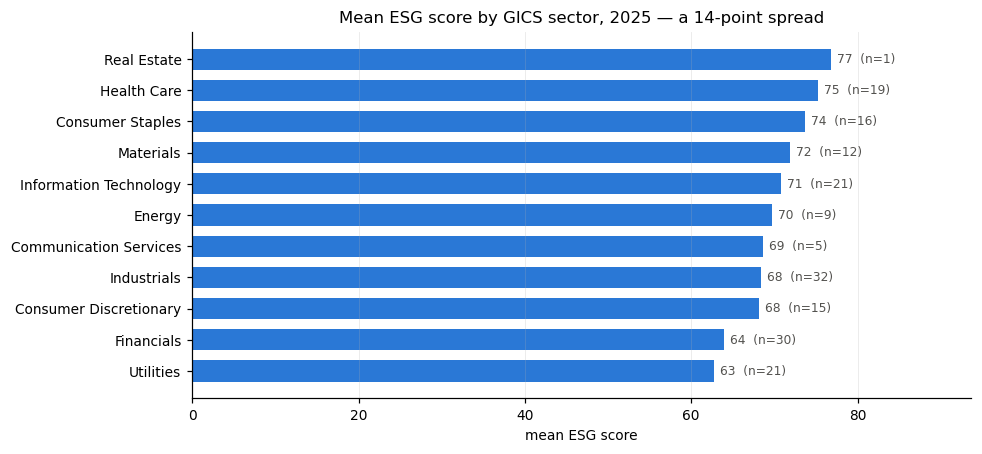

This spread is why the sector-neutral ranking exists. An unadjusted ESG sort buys
sector exposure first and company quality second.


In [37]:
sec = (latest.groupby("sector")["esg_score"]
       .agg(["mean", "count"]).sort_values("mean"))

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(sec.index, sec["mean"], color=Q_RAMP[2], height=0.68)
for sector, row in sec.iterrows():
    ax.annotate(f"{row['mean']:.0f}  (n={int(row['count'])})", (row["mean"], sector),
                textcoords="offset points", xytext=(4, 0), va="center",
                fontsize=8, color=NEUTRAL)
ax.set_xlim(0, sec["mean"].max() * 1.22)
ax.set_title(f"Mean ESG score by GICS sector, {FY0_YEAR} — a {sec['mean'].max() - sec['mean'].min():.0f}-point spread")
ax.set_xlabel("mean ESG score")
ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

print("This spread is why the sector-neutral ranking exists. An unadjusted ESG sort buys")
print("sector exposure first and company quality second.")

### Score persistence

If ESG rank barely changes year to year, quintiles are near-fixed company sets — return
differences would reflect stock-picking, not an ESG effect.

In [38]:
panel

,ticker,company,industry,esg_score,year,sector,esg_z,esg_group_rank
0,AAPL,Apple Inc,"Technology Hardware, Storage & Peripherals",51.746892,2005,Information Technology,0.503245,5.0
1,AAPL,Apple Inc,"Technology Hardware, Storage & Peripherals",44.975354,2006,Information Technology,0.000135,12.0
2,AAPL,Apple Inc,"Technology Hardware, Storage & Peripherals",37.280373,2007,Information Technology,-0.538906,15.0
3,AAPL,Apple Inc,"Technology Hardware, Storage & Peripherals",52.818926,2008,Information Technology,-0.297252,14.0
4,AAPL,Apple Inc,"Technology Hardware, Storage & Peripherals",61.933552,2009,Information Technology,0.044940,13.0
...,...,...,...,...,...,...,...,...
4077,YUM,Yum! Brands Inc,"Hotels, Restaurants & Leisure",82.939199,2021,Consumer Discretionary,0.859098,3.0
4078,YUM,Yum! Brands Inc,"Hotels, Restaurants & Leisure",80.340174,2022,Consumer Discretionary,0.798795,3.0
4079,YUM,Yum! Brands Inc,"Hotels, Restaurants & Leisure",77.410348,2023,Consumer Discretionary,0.613669,7.0
4080,YUM,Yum! Brands Inc,"Hotels, Restaurants & Leisure",79.662197,2024,Consumer Discretionary,0.786261,4.0


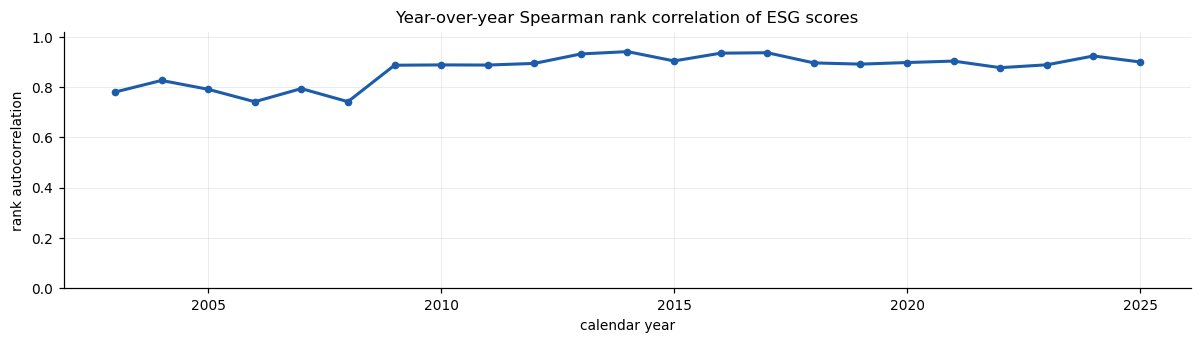

Mean rank autocorrelation (2006+): 0.883


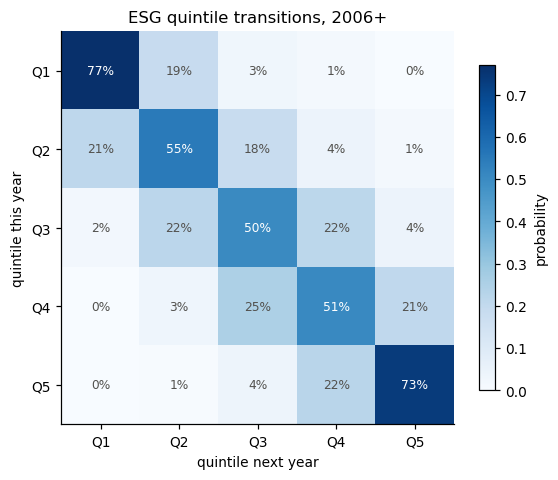

Probability of staying in the same quintile: 61% on average;
Q1 stays Q1 77% of the time, Q5 stays Q5 73%.


In [39]:
persist = rank_persistence(panel, "esg_score")

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(persist.index, persist.values, color=Q_RAMP[3], lw=2.0, marker="o", ms=4)
ax.set_ylim(0, 1.02)
ax.set_title("Year-over-year Spearman rank correlation of ESG scores")
ax.set_ylabel("rank autocorrelation"); ax.set_xlabel("calendar year")
fig.tight_layout(); plt.show()

print(f"Mean rank autocorrelation (2006+): {persist.loc[2006:].mean():.3f}")

q = assign_quintiles(panel, "esg_score")
wide_q = q.pivot_table(index="ticker", columns="year", values="bucket")
pairs = [(y0, y1) for y0, y1 in zip(sorted(wide_q.columns), sorted(wide_q.columns)[1:]) if y0 >= 2006]
trans = np.zeros((5, 5))
for y0, y1 in pairs:
    both = wide_q[[y0, y1]].dropna()
    for a, b in zip(both[y0].astype(int), both[y1].astype(int)):
        trans[a - 1, b - 1] += 1
trans = trans / trans.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(trans, cmap="Blues", vmin=0, vmax=trans.max())
for i in range(5):
    for j in range(5):
        ax.annotate(f"{trans[i, j]:.0%}", (j, i), ha="center", va="center", fontsize=8,
                    color="white" if trans[i, j] > trans.max() * 0.55 else NEUTRAL)
ax.set_xticks(range(5), [f"Q{i}" for i in range(1, 6)])
ax.set_yticks(range(5), [f"Q{i}" for i in range(1, 6)])
ax.set_xlabel("quintile next year"); ax.set_ylabel("quintile this year")
ax.set_title("ESG quintile transitions, 2006+")
ax.grid(visible=False)
fig.colorbar(im, ax=ax, shrink=0.8, label="probability")
fig.tight_layout(); plt.show()

print(f"Probability of staying in the same quintile: {np.diag(trans).mean():.0%} on average;")
print(f"Q1 stays Q1 {trans[0,0]:.0%} of the time, Q5 stays Q5 {trans[4,4]:.0%}.")

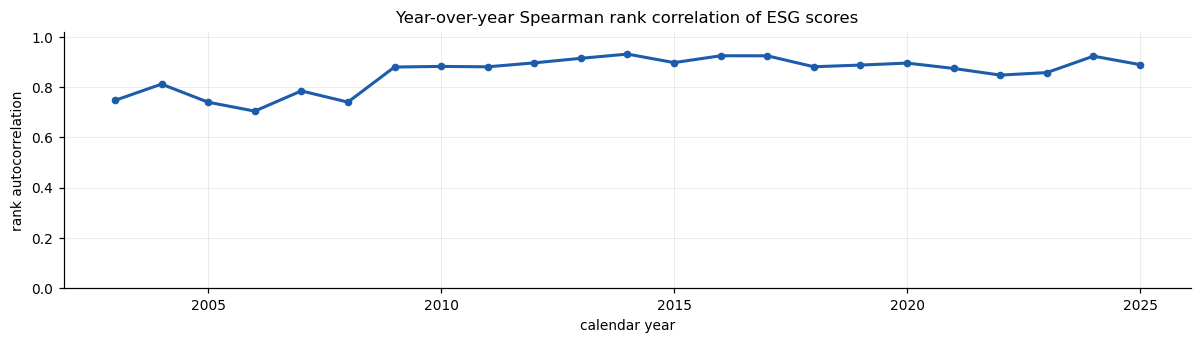

Mean rank autocorrelation (2006+): 0.871


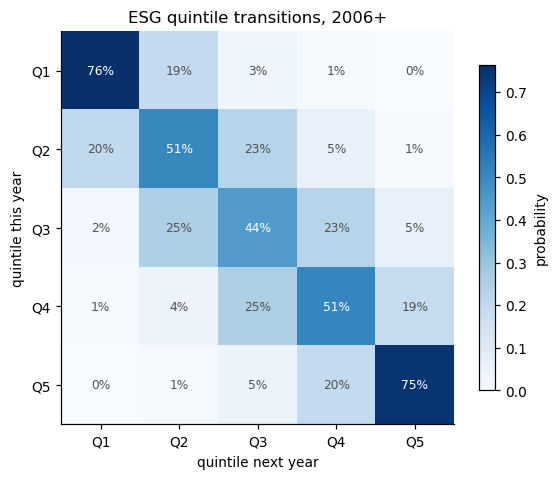

Probability of staying in the same quintile: 59% on average;
Q1 stays Q1 76% of the time, Q5 stays Q5 75%.


In [40]:
persist = rank_persistence(panel, "esg_z")

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(persist.index, persist.values, color=Q_RAMP[3], lw=2.0, marker="o", ms=4)
ax.set_ylim(0, 1.02)
ax.set_title("Year-over-year Spearman rank correlation of ESG scores")
ax.set_ylabel("rank autocorrelation"); ax.set_xlabel("calendar year")
fig.tight_layout(); plt.show()

print(f"Mean rank autocorrelation (2006+): {persist.loc[2006:].mean():.3f}")

q = assign_quintiles(panel, "esg_z")
wide_q = q.pivot_table(index="ticker", columns="year", values="bucket")
pairs = [(y0, y1) for y0, y1 in zip(sorted(wide_q.columns), sorted(wide_q.columns)[1:]) if y0 >= 2006]
trans = np.zeros((5, 5))
for y0, y1 in pairs:
    both = wide_q[[y0, y1]].dropna()
    for a, b in zip(both[y0].astype(int), both[y1].astype(int)):
        trans[a - 1, b - 1] += 1
trans = trans / trans.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(trans, cmap="Blues", vmin=0, vmax=trans.max())
for i in range(5):
    for j in range(5):
        ax.annotate(f"{trans[i, j]:.0%}", (j, i), ha="center", va="center", fontsize=8,
                    color="white" if trans[i, j] > trans.max() * 0.55 else NEUTRAL)
ax.set_xticks(range(5), [f"Q{i}" for i in range(1, 6)])
ax.set_yticks(range(5), [f"Q{i}" for i in range(1, 6)])
ax.set_xlabel("quintile next year"); ax.set_ylabel("quintile this year")
ax.set_title("ESG quintile transitions, 2006+")
ax.grid(visible=False)
fig.colorbar(im, ax=ax, shrink=0.8, label="probability")
fig.tight_layout(); plt.show()

print(f"Probability of staying in the same quintile: {np.diag(trans).mean():.0%} on average;")
print(f"Q1 stays Q1 {trans[0,0]:.0%} of the time, Q5 stays Q5 {trans[4,4]:.0%}.")

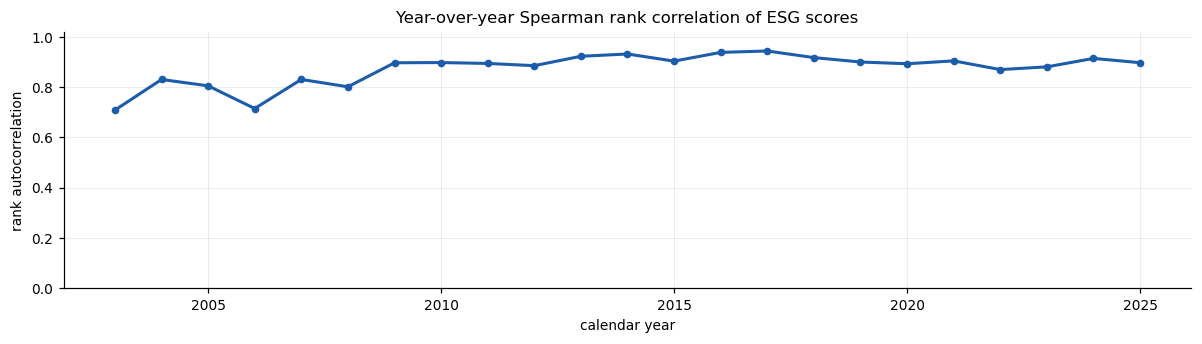

Mean rank autocorrelation (2006+): 0.887


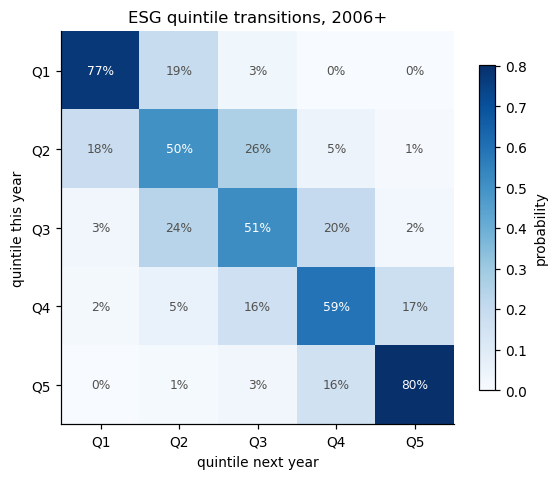

Probability of staying in the same quintile: 64% on average;
Q1 stays Q1 77% of the time, Q5 stays Q5 80%.


In [41]:
persist = rank_persistence(panel, "esg_group_rank")

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(persist.index, persist.values, color=Q_RAMP[3], lw=2.0, marker="o", ms=4)
ax.set_ylim(0, 1.02)
ax.set_title("Year-over-year Spearman rank correlation of ESG scores")
ax.set_ylabel("rank autocorrelation"); ax.set_xlabel("calendar year")
fig.tight_layout(); plt.show()

print(f"Mean rank autocorrelation (2006+): {persist.loc[2006:].mean():.3f}")

q = assign_quintiles(panel, "esg_group_rank")
wide_q = q.pivot_table(index="ticker", columns="year", values="bucket")
pairs = [(y0, y1) for y0, y1 in zip(sorted(wide_q.columns), sorted(wide_q.columns)[1:]) if y0 >= 2006]
trans = np.zeros((5, 5))
for y0, y1 in pairs:
    both = wide_q[[y0, y1]].dropna()
    for a, b in zip(both[y0].astype(int), both[y1].astype(int)):
        trans[a - 1, b - 1] += 1
trans = trans / trans.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(trans, cmap="Blues", vmin=0, vmax=trans.max())
for i in range(5):
    for j in range(5):
        ax.annotate(f"{trans[i, j]:.0%}", (j, i), ha="center", va="center", fontsize=8,
                    color="white" if trans[i, j] > trans.max() * 0.55 else NEUTRAL)
ax.set_xticks(range(5), [f"Q{i}" for i in range(1, 6)])
ax.set_yticks(range(5), [f"Q{i}" for i in range(1, 6)])
ax.set_xlabel("quintile next year"); ax.set_ylabel("quintile this year")
ax.set_title("ESG quintile transitions, 2006+")
ax.grid(visible=False)
fig.colorbar(im, ax=ax, shrink=0.8, label="probability")
fig.tight_layout(); plt.show()

print(f"Probability of staying in the same quintile: {np.diag(trans).mean():.0%} on average;")
print(f"Q1 stays Q1 {trans[0,0]:.0%} of the time, Q5 stays Q5 {trans[4,4]:.0%}.")

## Part C — Returns

Equal-weight quintiles, rebalanced annually.

ESG scores aren't public until 6–12mo after fiscal year-end.
`formation_lag_months=12` enforces this; `assert_no_lookahead` checks it, not just assumes it.

In [42]:
LAG = 12
results = {}
for label, col in [("absolute", "esg_score"), ("sector-neutral", "esg_z"), ("by-sector", "esg_group_rank")]:
    buckets = assign_quintiles(panel, col)
    bret = build_bucket_returns(buckets, returns, formation_lag_months=LAG)
    results[label] = {"buckets": buckets, "returns": bret, "summary": summarize_buckets(bret)}
    print(f"{label:>14}: {bret.index.min().date()} -> {bret.index.max().date()}, "
          f"{len(bret):,} days, scoring years {buckets.year.min()}-{buckets.year.max()}")

# Verification: membership is a clean partition, and coverage per year is visible.
b = results["absolute"]["buckets"]
assert b.groupby(["year", "ticker"]).size().max() == 1, "a ticker landed in two quintiles"
sizes = b.pivot_table(index="year", columns="bucket", values="ticker", aggfunc="count")
print("\nQuintile sizes per scoring year (first and last 3):")
print(pd.concat([sizes.head(3), sizes.tail(3)]).to_string())

      absolute: 2004-12-31 -> 2026-06-30, 5,407 days, scoring years 2003-2025
sector-neutral: 2004-12-31 -> 2026-06-30, 5,407 days, scoring years 2003-2025
     by-sector: 2004-12-31 -> 2026-06-30, 5,407 days, scoring years 2003-2025

Quintile sizes per scoring year (first and last 3):
bucket   1   2   3   4   5
year                      
2003    29  29  28  29  29
2004    30  30  30  30  30
2005    32  31  32  31  32
2023    37  36  36  36  36
2024    37  36  36  36  36
2025    37  36  36  36  36


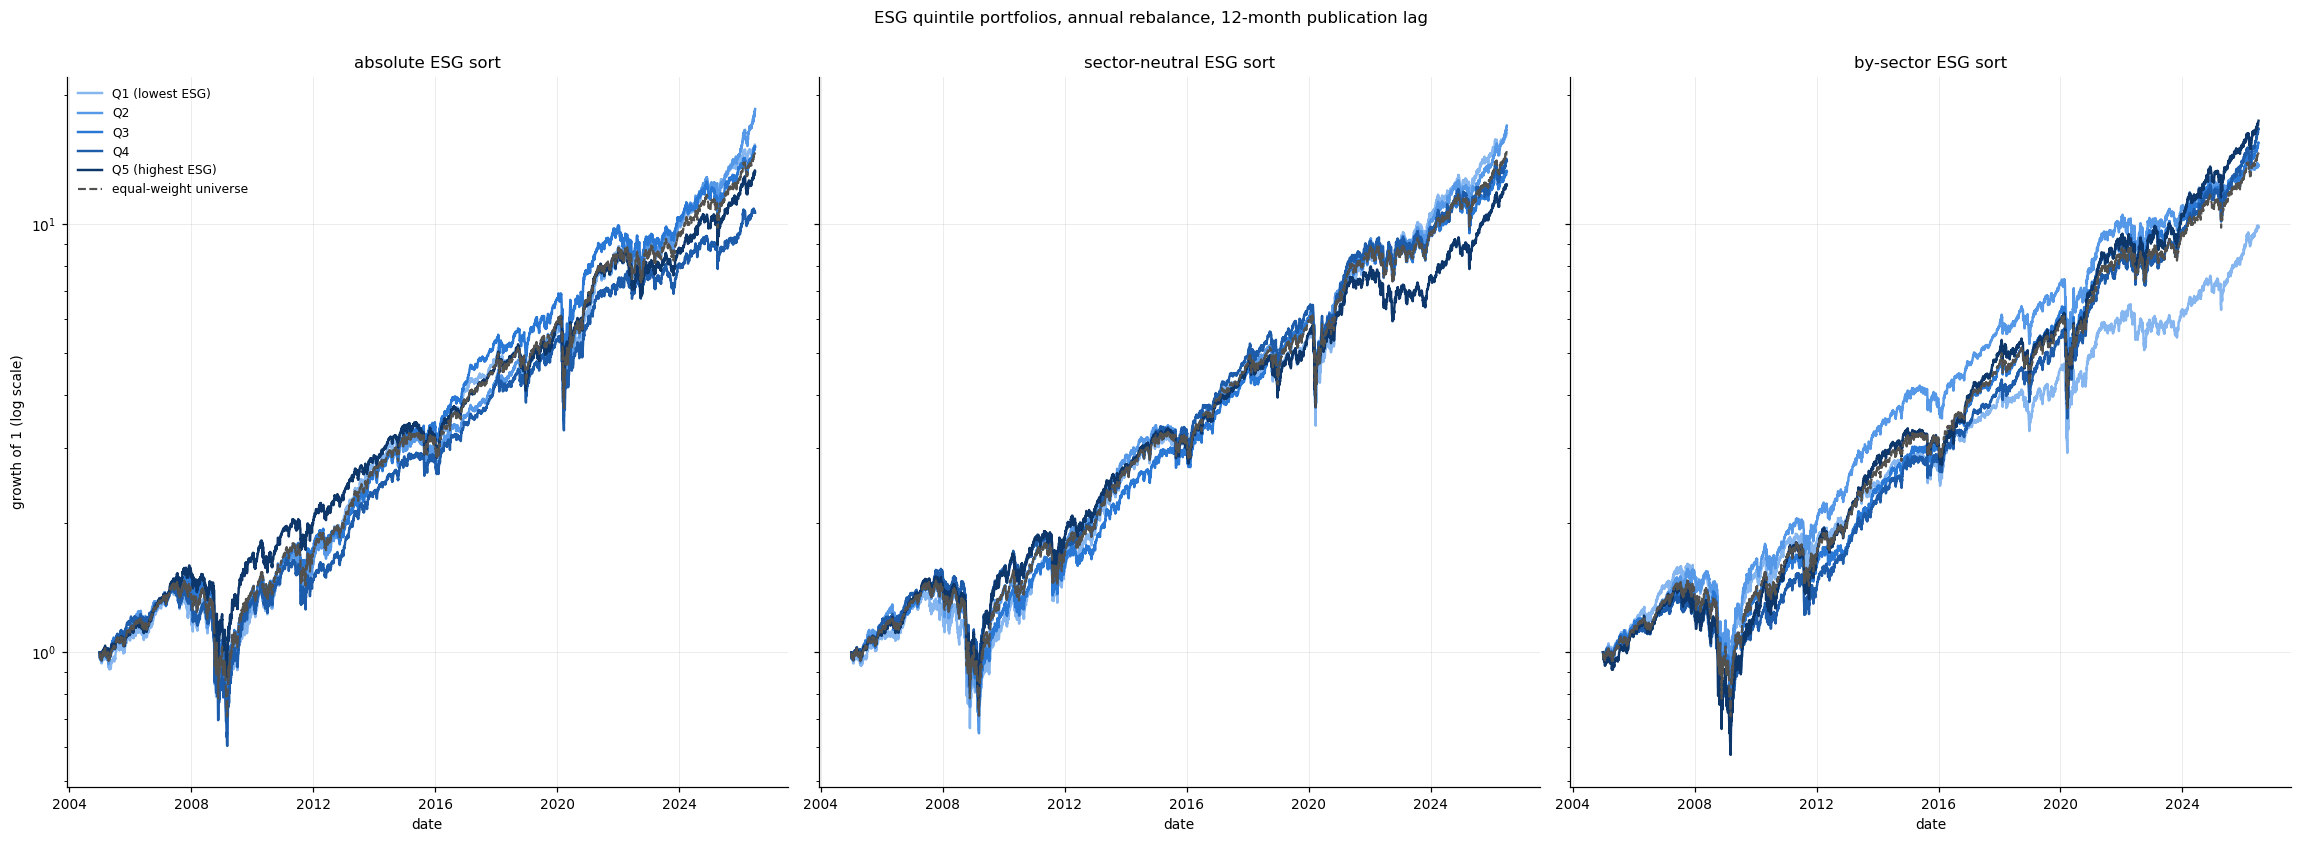

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7.6), sharey=True)
for ax, (label, res) in zip(axes, results.items()):
    bret = res["returns"]
    for i in range(1, 6):
        curve = (1 + bret[f"Q{i}"].fillna(0)).cumprod()
        ax.plot(curve.index, curve.values, color=Q_RAMP[i - 1], lw=1.6,
                label=f"Q{i}" + (" (lowest ESG)" if i == 1 else " (highest ESG)" if i == 5 else ""))
    bench = (1 + bret["EW_universe"].fillna(0)).cumprod()
    ax.plot(bench.index, bench.values, color=NEUTRAL, lw=1.4, ls="--", label="equal-weight universe")
    ax.set_yscale("log")
    ax.set_title(f"{label} ESG sort")
    ax.set_xlabel("date")
axes[0].set_ylabel("growth of 1 (log scale)")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle(f"ESG quintile portfolios, annual rebalance, {LAG}-month publication lag", y=1.0)
fig.tight_layout(); plt.show()

In [44]:
for label, res in results.items():
    s = res["summary"]
    print(f"{label.upper()} ESG sort".center(84, "-"))
    display(s.style.format({"ann_return": "{:.2%}", "ann_vol": "{:.2%}", "sharpe": "{:.2f}",
                            "cvar_5pct": "{:.2%}", "max_drawdown": "{:.1%}", "n_days": "{:,.0f}"}))
    q5, q1 = s.loc["Q5", "ann_return"], s.loc["Q1", "ann_return"]
    order = s.loc[[f"Q{i}" for i in range(1, 6)], "ann_return"]
    monotone = bool((order.diff().dropna() > 0).all() or (order.diff().dropna() < 0).all())
    print(f"Q5 - Q1 annualised return : {q5 - q1:+.2%}")
    print(f"Monotonic across quintiles: {monotone}")
    print(f"Q5 vs Q1 volatility       : {s.loc['Q5','ann_vol']:.2%} vs {s.loc['Q1','ann_vol']:.2%}")
    print(f"Q5 vs Q1 max drawdown     : {s.loc['Q5','max_drawdown']:.1%} vs {s.loc['Q1','max_drawdown']:.1%}\n")

---------------------------------ABSOLUTE ESG sort----------------------------------


,ann_return,ann_vol,sharpe,cvar_5pct,max_drawdown,n_days
portfolio,,,,,,
Q1,13.52%,20.83%,0.71,-3.15%,-53.9%,"5,407"
Q2,14.59%,20.66%,0.76,-3.09%,-57.2%,"5,407"
Q3,13.51%,19.51%,0.75,-2.92%,-49.2%,"5,407"
Q4,11.65%,19.42%,0.66,-2.96%,-57.7%,"5,407"
Q5,12.81%,18.72%,0.74,-2.79%,-45.1%,"5,407"
EW_universe,13.31%,19.45%,0.74,-2.95%,-51.9%,"5,407"


Q5 - Q1 annualised return : -0.71%
Monotonic across quintiles: False
Q5 vs Q1 volatility       : 18.72% vs 20.83%
Q5 vs Q1 max drawdown     : -45.1% vs -53.9%

------------------------------SECTOR-NEUTRAL ESG sort-------------------------------


,ann_return,ann_vol,sharpe,cvar_5pct,max_drawdown,n_days
portfolio,,,,,,
Q1,13.91%,20.51%,0.74,-3.11%,-52.6%,"5,407"
Q2,14.12%,20.05%,0.76,-3.02%,-56.0%,"5,407"
Q3,12.82%,19.12%,0.73,-2.88%,-52.9%,"5,407"
Q4,13.12%,19.85%,0.72,-2.98%,-50.0%,"5,407"
Q5,12.43%,19.34%,0.70,-2.90%,-50.3%,"5,407"
EW_universe,13.35%,19.42%,0.74,-2.94%,-51.7%,"5,407"


Q5 - Q1 annualised return : -1.48%
Monotonic across quintiles: False
Q5 vs Q1 volatility       : 19.34% vs 20.51%
Q5 vs Q1 max drawdown     : -50.3% vs -52.6%

---------------------------------BY-SECTOR ESG sort---------------------------------


,ann_return,ann_vol,sharpe,cvar_5pct,max_drawdown,n_days
portfolio,,,,,,
Q1,11.24%,19.13%,0.65,-2.88%,-50.7%,"5,407"
Q2,12.97%,19.20%,0.73,-2.88%,-47.0%,"5,407"
Q3,13.63%,19.01%,0.77,-2.87%,-48.9%,"5,407"
Q4,14.02%,19.54%,0.77,-2.94%,-54.7%,"5,407"
Q5,14.25%,22.33%,0.71,-3.36%,-60.3%,"5,407"
EW_universe,13.31%,19.45%,0.74,-2.95%,-51.9%,"5,407"


Q5 - Q1 annualised return : +3.01%
Monotonic across quintiles: True
Q5 vs Q1 volatility       : 22.33% vs 19.13%
Q5 vs Q1 max drawdown     : -60.3% vs -50.7%



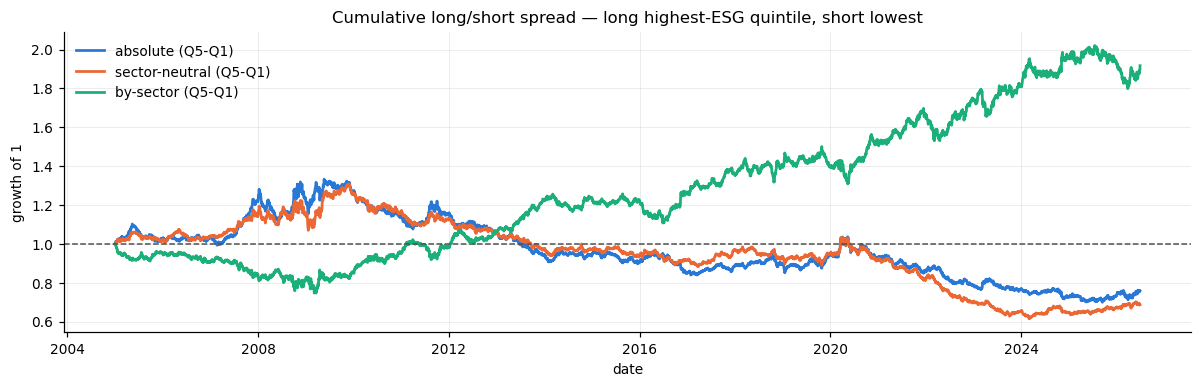

      absolute: spread annualised -1.28%
sector-neutral: spread annualised -1.73%
     by-sector: spread annualised +3.08%


In [45]:
fig, ax = plt.subplots(figsize=(11, 3.6))
for (label, res), colour in zip(results.items(), CAT):
    sp = spread_series(res["returns"]).dropna()
    ax.plot(sp.index, (1 + sp).cumprod().values, color=colour, lw=1.8, label=f"{label} (Q5-Q1)")
ax.axhline(1.0, color=NEUTRAL, lw=1.0, ls="--")
ax.set_title("Cumulative long/short spread — long highest-ESG quintile, short lowest")
ax.set_ylabel("growth of 1"); ax.set_xlabel("date")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()

for label, res in results.items():
    sp = spread_series(res["returns"]).dropna().to_numpy()
    print(f"{label:>14}: spread annualised {annualized_return(sp):+.2%}")

### Sensitivity: value of the publication lag

Re-run with `lag=0` (score usable same-day as fiscal year-end, unrealistic). The gap vs.
`lag=12` is the look-ahead premium.

,Q1_ann,Q5_ann,Q5_minus_Q1
lag_months,,,
0,+13.59%,+11.64%,-1.95%
6,+13.22%,+11.96%,-1.25%
12,+13.52%,+12.81%,-0.71%
18,+14.03%,+12.61%,-1.42%


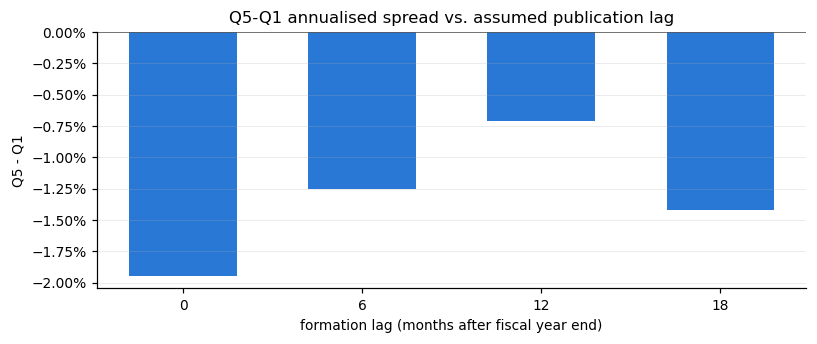

Look-ahead premium (lag 0 vs 12): -1.24% of annualised spread.


In [46]:
sens = []
buckets_abs = assign_quintiles(panel, "esg_score")
for lag in (0, 6, 12, 18):
    bret = build_bucket_returns(buckets_abs, returns, formation_lag_months=lag)
    s = summarize_buckets(bret)
    sens.append({"lag_months": lag,
                 "Q1_ann": s.loc["Q1", "ann_return"], "Q5_ann": s.loc["Q5", "ann_return"],
                 "Q5_minus_Q1": s.loc["Q5", "ann_return"] - s.loc["Q1", "ann_return"]})
sens = pd.DataFrame(sens).set_index("lag_months")
display(sens.style.format("{:+.2%}"))

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.bar(sens.index.astype(str), sens["Q5_minus_Q1"], color=Q_RAMP[2], width=0.6)
ax.axhline(0, color=NEUTRAL, lw=1.0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Q5-Q1 annualised spread vs. assumed publication lag")
ax.set_xlabel("formation lag (months after fiscal year end)")
ax.set_ylabel("Q5 - Q1")
ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

print(f"Look-ahead premium (lag 0 vs 12): "
      f"{sens.loc[0,'Q5_minus_Q1'] - sens.loc[12,'Q5_minus_Q1']:+.2%} of annualised spread.")

## Part D — FY0 pillar snapshot

**Cross-sectional only, no time series.** Can't run returns against a single-year snapshot.

**Scale warning:** pillars are 0–5, combined ESG score is 0–100. Never mix without rescaling.

181 of 181 names have complete pillar data



,min,max
e_pillar,0.75,4.50
s_pillar,0.00,4.57
g_pillar,2.20,4.50
controversies,0.00,5.00
esg_score,35.70,89.43


Pillars and Controversies are 0-5; the combined ESG Score is 0-100. Different units.


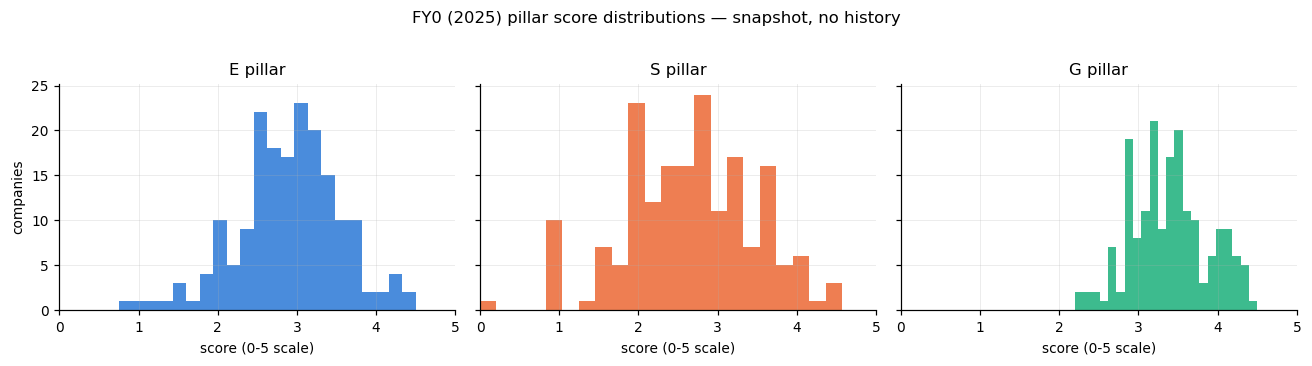

Correlation among pillars, combined score and controversies:


,e_pillar,s_pillar,g_pillar,esg_score,controversies
e_pillar,1.00,0.39,0.22,0.48,0.03
s_pillar,0.39,1.00,0.36,0.56,0.13
g_pillar,0.22,0.36,1.00,0.37,0.13
esg_score,0.48,0.56,0.37,1.00,0.21
controversies,0.03,0.13,0.13,0.21,1.00


In [47]:
pillars = ["e_pillar", "s_pillar", "g_pillar"]
snap = snapshot.dropna(subset=pillars + ["esg_score"]).copy()
print(f"{len(snap)} of {len(snapshot)} names have complete pillar data\n")

ranges = snap[pillars + ["controversies", "esg_score"]].agg(["min", "max"]).T
display(ranges.style.format("{:.2f}"))
assert ranges.loc[pillars, "max"].max() <= 5.0, "pillars are not on the expected 0-5 scale"
assert ranges.loc["esg_score", "max"] > 50.0, "combined score is not on the expected 0-100 scale"
print("Pillars and Controversies are 0-5; the combined ESG Score is 0-100. Different units.")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, pillar, colour in zip(axes, pillars, CAT):
    ax.hist(snap[pillar], bins=22, color=colour, alpha=0.85)
    ax.set_title(f"{pillar.split('_')[0].upper()} pillar")
    ax.set_xlabel("score (0-5 scale)")
    ax.set_xlim(0, 5)
axes[0].set_ylabel("companies")
fig.suptitle(f"FY0 ({FY0_YEAR}) pillar score distributions — snapshot, no history", y=1.02)
fig.tight_layout(); plt.show()

corr = snap[pillars + ["esg_score", "controversies"]].corr()
print("Correlation among pillars, combined score and controversies:")
display(corr.style.format("{:.2f}").background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))

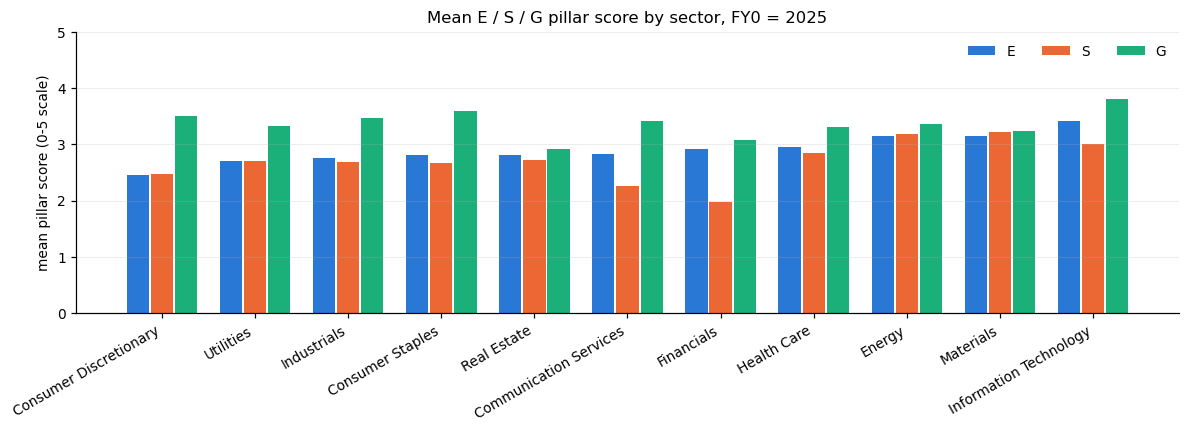

Cross-sector spread, widest first (0-5 scale):
  S: 1.24
  E: 0.95
  G: 0.89

S varies most across sectors (1.24); G varies least (0.89).
Note this is NOT the intuitive result - Environmental is not the widest-varying
pillar here, despite E being the most physically industry-determined. Worth
checking against the vendor's pillar methodology before building on it.


In [49]:
by_sector = snap.groupby("sector")[pillars].mean().sort_values("e_pillar")
x = np.arange(len(by_sector)); width = 0.26

fig, ax = plt.subplots(figsize=(11, 4.0))
for i, (pillar, colour) in enumerate(zip(pillars, CAT)):
    ax.bar(x + (i - 1) * width, by_sector[pillar], width=width * 0.92,
           color=colour, label=pillar.split("_")[0].upper())
ax.set_xticks(x, by_sector.index, rotation=30, ha="right")
ax.set_ylabel("mean pillar score (0-5 scale)")
ax.set_ylim(0, 5)
ax.set_title(f"Mean E / S / G pillar score by sector, FY0 = {FY0_YEAR}")
ax.legend(frameon=False, ncol=3)
ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

# Derive the ordering from the data rather than asserting it - the ranking is not the one
# intuition suggests, and a hard-coded sentence here would have been wrong.
spread = (by_sector.max() - by_sector.min()).sort_values(ascending=False)
print("Cross-sector spread, widest first (0-5 scale):")
for pillar, value in spread.items():
    print(f"  {pillar.split('_')[0].upper()}: {value:.2f}")
widest, narrowest = spread.index[0], spread.index[-1]
print(f"\n{widest.split('_')[0].upper()} varies most across sectors "
      f"({spread.iloc[0]:.2f}); {narrowest.split('_')[0].upper()} varies least "
      f"({spread.iloc[-1]:.2f}).")
print("Note this is NOT the intuitive result - Environmental is not the widest-varying")
print("pillar here, despite E being the most physically industry-determined. Worth")
print("checking against the vendor's pillar methodology before building on it.")

## Summary

**Data.** usable range: 2003–2025, combined score only (no pillar history). Pillars are
0–5 vs. score's 0–100 — different units.

**Ranking.** Raw vs sector-neutral top-20 overlap only partially. ESG rank is partly a
sector bet.

**Persistence.** Rank autocorrelation ~0.9

**Returns.** No return effect, no monotonic Q1 Q5 pattern, Q5 Q1 spread small/negative. Real
pattern is on risk: top ESG quintile has lower vol and shallower drawdown.

**Open items:**
- Scores are as-restated-today, not as-published-then
- Universe is survivors-only don't quote absolute returns, only quintile diffs